In [1]:
import torch
from torch import optim

import os
import logging
from IPython import display
import numpy as np
import matplotlib.pyplot as plt

from trainer import Trainer
from tools.load_data import get_device, load_data
from experiment import ExperimentScheduler as ExperimentWithScheduler
from optim.optimiser_netline_v3 import NetLine
from optim.optimiser_dz_v3 import NetDz
from optim.scheduler_netline import CosineAnnealingNetLine
from optim.utils import MetaData
from nets.cnn import _make_resnet18v2, make_resnet18v2
from tools.recorder import ExperimentsRecorder
from optim.optimizer_pack1 import Lookahead

# =====================
import sys 
from pathlib import Path

os.makedirs(".data_experiments", exist_ok=True)
os.makedirs("logs", exist_ok=True)

device = get_device()


In [2]:
EPOCHS_PER_EXPERIMENT = 50

In [3]:
logging.basicConfig(filename="logs/exp100.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")

def clone_resnet18v2(model, meta):
    mdl = _make_resnet18v2(meta.output_dim).to(device)
    mdl.load_state_dict(model.state_dict())
    return mdl

train_dl, test_dl = load_data('CIFAR10')
model = make_resnet18v2(train_dl).to(device)

meta = MetaData(output_dim=10, device=device)

lr1 = 5e-5
lr_max = 0.02
val_momentum = 0.9

#Netline
nl_opt = NetLine(model=model, meta=meta, lr1=lr1, momentum=val_momentum, weight_decay=5e-3)
nl_opt.lr_averaging_queue_size = 50
nl_sch = CosineAnnealingNetLine(optimizer = nl_opt, lr_max=lr_max,\
                                epochs_per_experiment = EPOCHS_PER_EXPERIMENT, epochs_warmup = 3, epochs_shutdown = 0)
exp_netline = ExperimentWithScheduler("netline", model, nl_opt, nl_sch, do_optimiser_step=False)

#Dz
model_dz = clone_resnet18v2(model, meta)

dz_opt = NetDz(model=model_dz, meta=meta, lr1=lr1, momentum=val_momentum, weight_decay=5e-3)
dz_opt.lr_averaging_queue_size = 50
dz_sch = CosineAnnealingNetLine(optimizer = dz_opt, lr_max=lr_max,\
                                epochs_per_experiment = EPOCHS_PER_EXPERIMENT, epochs_warmup = 3, epochs_shutdown = 0)
exp_dz = ExperimentWithScheduler("dz", model_dz, dz_opt, dz_sch, do_optimiser_step=False)

#Lookahead
model_lookahead = clone_resnet18v2(model, meta)
opt_sgd_lookahead = optim.SGD(model_lookahead.parameters(), lr=lr_max, momentum=val_momentum, weight_decay=5e-3)
opt_lookahead = Lookahead(opt_sgd_lookahead)
schd_lookahead = optim.lr_scheduler.CosineAnnealingLR(opt_lookahead, T_max=EPOCHS_PER_EXPERIMENT)
exp_lookahead = ExperimentWithScheduler("lookahead", model_lookahead, opt_lookahead, schd_lookahead, do_optimiser_step=True)

#Sgd
model_sgd = clone_resnet18v2(model, meta)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=lr_max, momentum=val_momentum, weight_decay=5e-3)
schd_sgd = optim.lr_scheduler.CosineAnnealingLR(opt_sgd, T_max=EPOCHS_PER_EXPERIMENT)
exp_sgd = ExperimentWithScheduler("sgd", model_sgd, opt_sgd, schd_sgd, do_optimiser_step=True)

experiments = [exp_netline, exp_dz, exp_lookahead, exp_sgd]

d:\Programs-python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


training size: 50000 -> 128 x 391      validation size: 10000 -> 1024 x 10


In [15]:
def experiment_comparison(exp_recorder, title="Comparison"):

    MEAN_LA = exp_recorder['lookahead']
    MEAN_NETLINE = exp_recorder['netline']
    MEAN_DZ = exp_recorder['dz']
    MEAN_SGD = exp_recorder['sgd']
    #cord_x = np.arange(0, len(MEAN_NETLINE[:,22]))  'test_loss' : test_res[0],   'test_error'

    #display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    axes[0].set_title('Test loss (average cross entropy) per epoch')
    axes[0].plot(MEAN_LA['test_loss'], color='g',alpha=.5, label='Lookahead')
    axes[0].plot(MEAN_NETLINE['test_loss'], color='b',alpha=.5, label='Net-line')
    axes[0].plot(MEAN_DZ['test_loss'], color='orange',alpha=.5, label='Dz')
    axes[0].plot(MEAN_SGD['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Test error (top 1) mean per epoch')
    axes[1].plot(MEAN_LA['test_error'], color='g', alpha=.5, label='Lookahead')
    axes[1].plot(MEAN_NETLINE['test_error'], color='b', alpha=.5, label='Net-line')
    axes[1].plot(MEAN_DZ['test_error'], color='orange', alpha=.5, label='Dz')
    axes[1].plot(MEAN_SGD['test_error'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].set_yscale("log")
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Error value")

    '''
    axes[1,0].set_title('PQ norm mean per epoch')
    axes[1,0].plot(MEAN_ADAM[:,4], color='g',alpha=.5, label='PQ norm, Lookahead')
    axes[1,0].plot(MEAN_NETLINE[:,4], color='b',alpha=.5, label='PQ norm, Net-line')
    axes[1,0].fill_between(x=cord_x, y1=MEAN_NETLINE[:,4]-MEAN_NETLINE[:,12], y2=MEAN_NETLINE[:,4]+MEAN_NETLINE[:,12], color='b', alpha=.125)
    axes[1,0].plot(MEAN_SGD[:,4], color='grey',alpha=.5, label='PQ norm, SGD')
    axes[1,0].plot(MEAN_ADAM[:,7], color='g',alpha=.5, linestyle='dashed', label='PQ1 norm, Lookahead')
    axes[1,0].plot(MEAN_NETLINE[:,7], color='b',alpha=.5, linestyle='dashed', label='PQ1 norm, Net-line')
    axes[1,0].plot(MEAN_SGD[:,7], color='grey',alpha=.5, linestyle='dashed', label='PQ1 norm, SGD')
    axes[1,0].grid()
    axes[1,0].legend()

    axes[1,1].set_title('QQ1 vector norm mean per epoch')
    axes[1,1].set_yscale("log")
    axes[1,1].plot(MEAN_NETLINE[:,3], color='orange',alpha=.5, linestyle='dashed',label='QQ1 vector norm/eta1, Net-line')
    axes[1,1].plot(MEAN_ADAM[:,10], color='g',alpha=.5, label='QQ2 vector norm/eta2, Lookahead')
    axes[1,1].plot(MEAN_NETLINE[:,10], color='b',alpha=.5, label='QQ2 vector norm/eta2, Net-line')
    axes[1,1].plot(MEAN_SGD[:,10], color='grey',alpha=.5, label='QQ2 vector norm/eta2, SGD')
    axes[1,1].grid()
    axes[1,1].legend()

    axes[2,0].set_title('Cos phi and alpha mean per epoch')
    axes[2,0].plot(MEAN_ADAM[:,5], color='g',alpha=.5, label='Cos phi, Lookahead')
    axes[2,0].plot(MEAN_NETLINE[:,5], color='b',alpha=.5, label='Cos phi, Net-line')
    axes[2,0].fill_between(x=cord_x, y1=MEAN_NETLINE[:,5]-MEAN_NETLINE[:,13], y2=MEAN_NETLINE[:,5]+MEAN_NETLINE[:,13], color='b', alpha=.125)
    axes[2,0].plot(MEAN_SGD[:,5], color='grey',alpha=.5, label='Cos phi, SGD')
    axes[2,0].plot(MEAN_NETLINE[:,15], color='magenta',alpha=.5, label='Alpha summary, Net-line')
    axes[2,0].grid()
    axes[2,0].legend()

    axes[2,1].set_title('Eta calculated')
    axes[2,1].set_yscale("log")
    axes[2,1].plot(MEAN_NETLINE[:,6], color='magenta', linestyle='dashed', alpha=.5, label='Eta2 averaged mean per epoch')
    axes[2,1].fill_between(x=cord_x, y1=MEAN_NETLINE[:,6]-MEAN_NETLINE[:,20], y2=MEAN_NETLINE[:,6]+MEAN_NETLINE[:,20], color='magenta', alpha=.125)
    axes[2,1].plot(MEAN_NETLINE[:,21], color='blue',alpha=.5, label='Eta2 no-averaged mean plus-minus one sigma per epoch')
    axes[2,1].fill_between(x=cord_x, y1=MEAN_NETLINE[:,21]-MEAN_NETLINE[:,22], y2=MEAN_NETLINE[:,21]+MEAN_NETLINE[:,22], color='blue', alpha=.125)
    axes[2,1].plot(MEAN_NETLINE[:,11], color='magenta', alpha=.25, label='eta_base')

    axes[2,1].plot(MEAN_SGD[:,6], color='grey', alpha=.5, label='Eta SGD mean per epoch')
    axes[2,1].grid()
    axes[2,1].legend()
    '''

    dummy=fig.suptitle(title)
    plt.show()

def accuracy_comparison(exp_recorder, title="Validation accuracy"):
    def rf(value):
        return f"{value:.5f}"

    ACC_LA = 1.0 - np.array(exp_recorder['lookahead']['test_error'])
    ACC_NETLINE = 1.0 - np.array(exp_recorder['netline']['test_error'])
    ACC_DZ = 1.0 - np.array(exp_recorder['dz']['test_error'])
    ACC_SGD = 1.0 - np.array(exp_recorder['sgd']['test_error'])

    p1, p2, p3, p4, p5 = min(10,EPOCHS_PER_EXPERIMENT), min(20,EPOCHS_PER_EXPERIMENT), min(30,EPOCHS_PER_EXPERIMENT)\
        , min(40,EPOCHS_PER_EXPERIMENT), min(100,EPOCHS_PER_EXPERIMENT)

    report = np.zeros((4,5), dtype='U256')
    for row in range(4):
        acc = ACC_LA if row == 0 else ACC_NETLINE if row == 1 else ACC_DZ if row == 2 else ACC_SGD
        for col in range(5):
            indx = p1 if col == 0 else p2 if col == 1 else p3 if col == 2 else p4 if col == 3 else p5
            report[row, col] = rf(max(acc[0:indx]))

    fig, ax = plt.subplots(figsize=(8, 8))
    # hide axes
    #fig.patch.set_visible(False)
    ax.axis('off')
    ax.axis('tight')

    tab_plot = ax.table(cellText=report, colLabels=[str(p1)+' epochs',str(p2)+' epochs',str(p3)+' epochs',str(p4)+' epochs',str(p5)+' epochs']\
        , rowLabels=['Lookahead','Net-line', 'Dz','SGD'], cellLoc='left', loc='center')
    tab_plot.auto_set_font_size(False)
    tab_plot.set_fontsize(11)
    tab_plot.scale(3, 5)
    #fig.tight_layout()
    ax.set_title(title)
    plt.show()

In [ ]:
trainers = []
exp_recorder = ExperimentsRecorder()

for exp in experiments:
    tn = Trainer(exp.model, exp.optimizer, exp.scheduler, experiment_name = exp.name, verbose = 0, \
                         do_optimiser_step = hasattr(exp, 'do_optimiser_step') and exp.do_optimiser_step)
    trainers.append(tn)
    exp_recorder[exp.name] = tn.recorder

for tn in trainers:
    tn.recorder.restart()

for epoch in range(EPOCHS_PER_EXPERIMENT):
    print(f"Epoch {epoch+1} starting")
    for tn in trainers:
        tn.train_loop_init()

    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        for tn in trainers:
            tn.train_step(images, labels)

    print(f"Epoch {epoch+1} train finished")

    for tn in trainers:
        tn.train_loop_close(test_dl)

    print(f"Epoch {epoch+1} check finished")
    display.clear_output()
    experiment_comparison(exp_recorder, "Error and loss, current experiment")



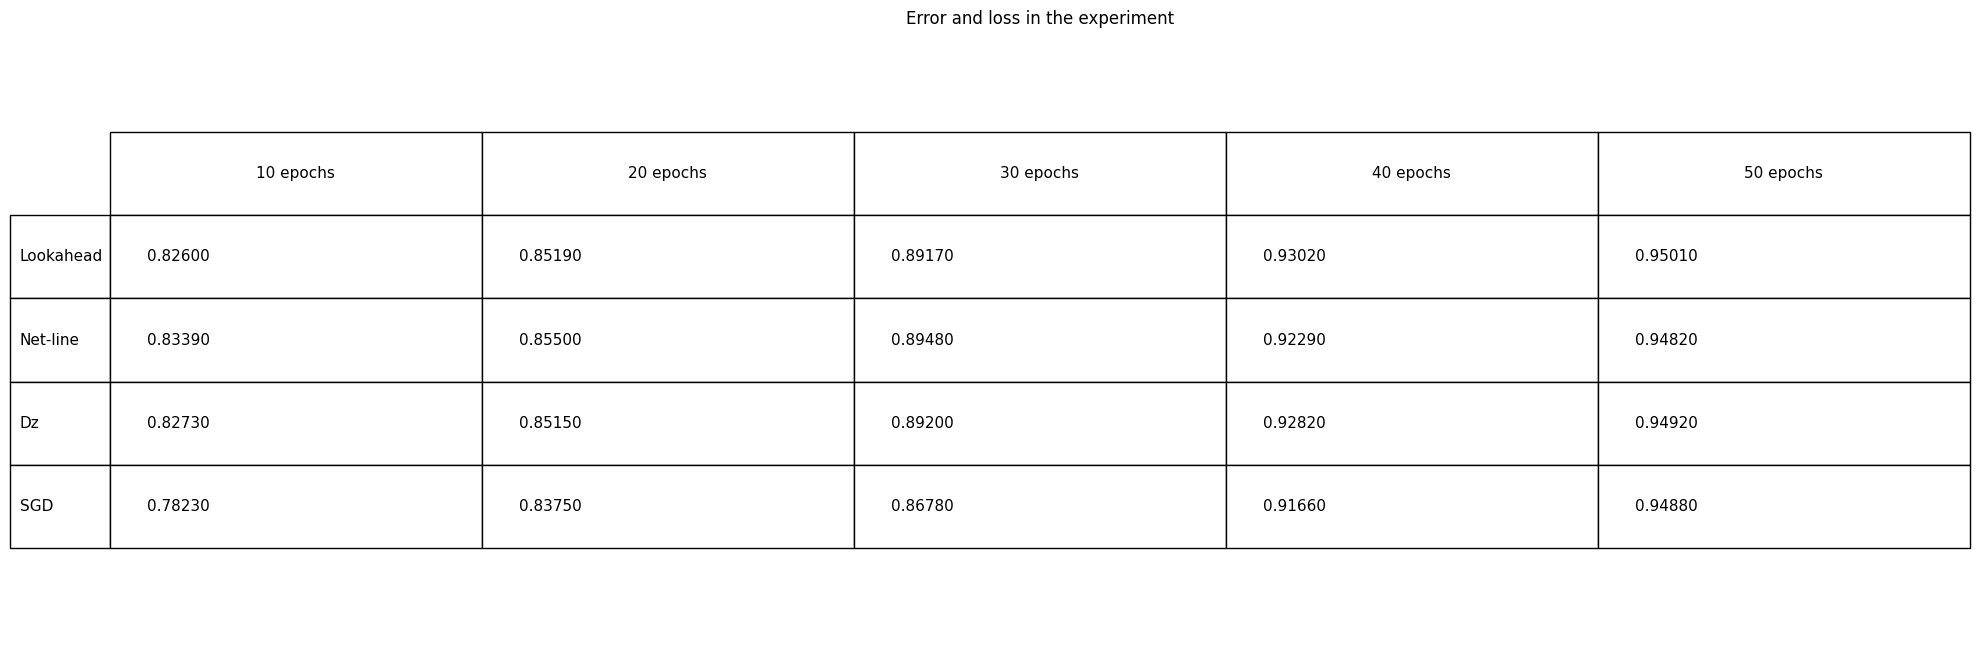

In [16]:
title3 = "Error and loss in the experiment".format(exp_recorder)
accuracy_comparison(exp_recorder, title=title3)